# Data analysis

This notebook assumes the previous execution of the `tools/filter.sh` script to generate a CSV from the raw PCAP file.
`filter.sh` is a simple script for tshark. By default, it uses first 4096 packets for simplicity.

## Introduction
The notebook is structured as follows:

- Packet level analysis

- Flow level analysis

In [2]:
import pandas as pd

fname = "dataset/201302011400-4096.csv"

df = pd.read_csv(fname)

df.head()

,frame.number,frame.time_relative,frame.time_delta,frame.len,ip.src,ip.dst,ip.proto,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport
0,1,0.000000,NaN,1514,200.11.79.20,140.198.115.132,6,80.0,52021.0,NaN,NaN
1,2,0.000003,0.000003,1514,200.11.79.20,140.198.115.132,6,80.0,52021.0,NaN,NaN
2,3,0.000006,0.000003,1514,200.11.79.20,140.198.115.132,6,80.0,52021.0,NaN,NaN
3,4,0.000009,0.000003,94,167.180.134.255,32.218.92.255,1,NaN,NaN,NaN,NaN
4,5,0.000012,0.000003,66,55.146.64.212,211.83.168.117,6,49191.0,3389.0,NaN,NaN


# Packet size analysis

First, we extract the packet_size from the `frame.len` field of the initial dataset.

Looking at the distribution plotted, it could be fit with the bi-modal distribution. This can be explained as follows:

- **left peak**: small size packet usually used control traffic (handshake, acks)
- **right peak**: `1500` bytes packets. Most OS tend to use all availble MTU for frames

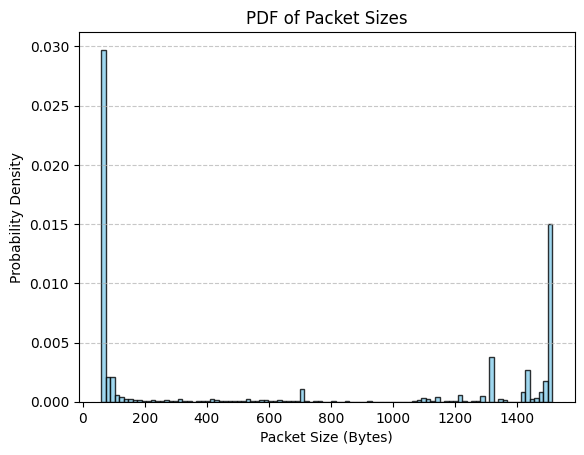

In [10]:
import matplotlib.pyplot as plt

packet_sizes = df["frame.len"].dropna()

plt.hist(packet_sizes, bins=100, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('PDF of Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("figures/packet_size.pdf")

# Fit wit the distribution

# Inter-arrival time analysis

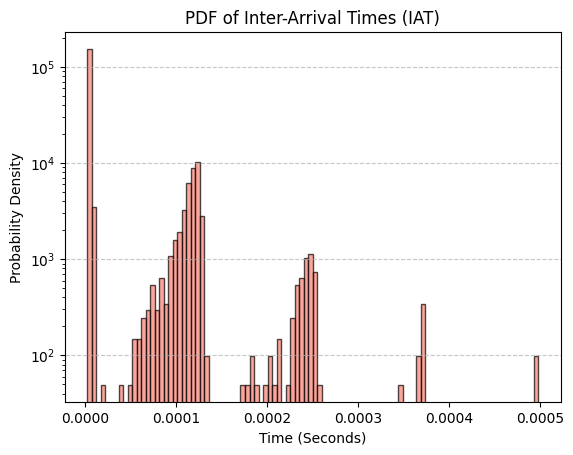

In [8]:
import matplotlib.pyplot as plt

iat_data = df["frame.time_delta"].dropna()

plt.hist(iat_data, bins=100, density=True, color='salmon', edgecolor='black', alpha=0.7)
plt.title('PDF of Inter-Arrival Times (IAT)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Probability Density')
plt.yscale('log') # Useful if you have a few very large gaps
plt.grid(axis='y', linestyle='--', alpha=0.7)